# 14 · Output analysis

A simulation is a statistical experiment, and its outputs - waits of successive customers, daily costs, MCMC
draws - are usually autocorrelated and start in an unrepresentative state. Treating them as i.i.d. gives
intervals that are far too narrow. This notebook quantifies autocorrelation (the integrated autocorrelation
time), builds honest intervals (batch means, replications, the regenerative method), and deals with the
initial transient (Welch's plot, MSER).

**What you will learn**
- measure autocorrelation with the integrated autocorrelation time
- build valid intervals by batch means, replications and regeneration
- detect and remove the initial transient
- plan run lengths for a target precision

**Before you start:** notebooks 02 and 13  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from engstoch import output as oa, queues as qu, montecarlo as mc
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Autocorrelated output

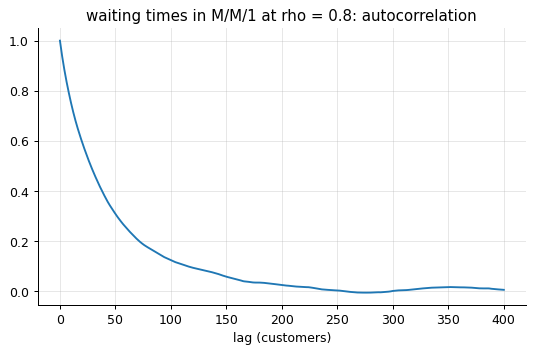

integrated autocorrelation time tau = 93 (window 464): 190000 waits carry the information of 2049 independent ones
naive i.i.d. standard error 0.0120; corrected sqrt(tau) x = 0.1154


In [2]:
n = 200_000
w = qu.lindley(R(1).exponential(1 / 0.8, n), R(2).exponential(1.0, n))
acf = oa.autocorrelation(w[10_000:], 400)
plt.plot(acf); plt.xlabel("lag (customers)"); plt.title("waiting times in M/M/1 at rho = 0.8: autocorrelation"); plt.show()
it = oa.iat(w[10_000:])
naive = mc.mean_ci(w[10_000:])
print(f"integrated autocorrelation time tau = {it['tau']:.0f} (window {it['window']}): {n - 10_000} waits carry the information of {it['ess']:.0f} independent ones")
print(f"naive i.i.d. standard error {naive['std_error']:.4f}; corrected sqrt(tau) x = {naive['std_error'] * np.sqrt(it['tau']):.4f}")

Successive waits share most of their history, so they are strongly correlated: the variance of their mean is
τσ²/n with τ = 1 + 2Σρ(k), here about 90. The naive interval is ten times too narrow. Sokal's automatic
window - sum the autocorrelations up to the smallest M with M ≥ 5τ(M) - balances the bias of truncation against
the noise of distant lags.

## Batch means

In [3]:
rows = []
for nb in (5, 10, 20, 40, 100, 400):
    b = oa.batch_means(w[10_000:], nb)
    rows.append((nb, b["batch_size"], b["estimate"], b["std_error"], b["lag1_corr"]))
print(pd.DataFrame(rows, columns=["batches", "batch size", "mean wait", "std error", "lag-1 corr of batch means"]).to_string(index=False, float_format="%.4f"))
print("truth Wq = 4.0")
cov = []
for k in range(300):
    x = qu.lindley(R(1000 + k).exponential(1 / 0.8, 20_000), R(2000 + k).exponential(1.0, 20_000))[2000:]
    cov.append((oa.batch_means(x, 20)["ci"], mc.mean_ci(x)["ci"]))
print(f"coverage of 95 % intervals over 300 runs: batch means {oa.coverage([c[0][0] for c in cov], [c[0][1] for c in cov], 4.0)['coverage']:.3f} | naive {oa.coverage([c[1][0] for c in cov], [c[1][1] for c in cov], 4.0)['coverage']:.3f}")

 batches  batch size  mean wait  std error  lag-1 corr of batch means
       5       38000     4.1919     0.1059                    -0.1984
      10       19000     4.1919     0.1065                    -0.3105
      20        9500     4.1919     0.1178                    -0.0237
      40        4750     4.1919     0.1201                     0.0080
     100        1900     4.1919     0.1156                    -0.0775
     400         475     4.1919     0.1076                     0.0562
truth Wq = 4.0


coverage of 95 % intervals over 300 runs: batch means 0.900 | naive 0.133


Batch means of long enough batches are nearly independent; their t interval is valid. Too many short batches
leave correlation between them (visible in the lag-1 correlation) and understate the error. Even batch means
undercover at short run lengths in heavy traffic - 18 000 customers at ρ = 0.8 is not much - but they are
vastly better than the naive interval.

## The initial transient

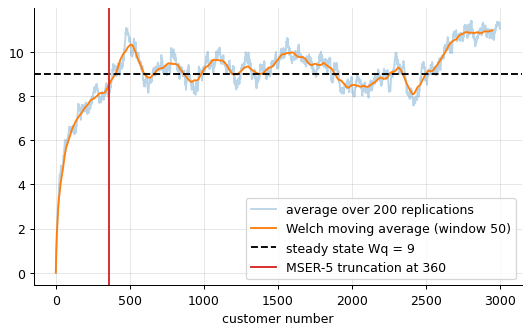

mean of the first 500 waits 7.57, of the rest 9.39


In [4]:
reps = np.array([qu.lindley(R(3000 + k).exponential(1 / 0.9, 3000), R(4000 + k).exponential(1.0, 3000) * 1.0) for k in range(200)])
wma = oa.welch_moving_average(reps, 50)
plt.plot(reps.mean(axis=0), alpha=0.3, label="average over 200 replications"); plt.plot(wma, label="Welch moving average (window 50)"); plt.axhline(9.0, color="k", ls="--", label="steady state Wq = 9")
cut = oa.mser(reps.mean(axis=0))["truncate"]
plt.axvline(cut, color="C3", label=f"MSER-5 truncation at {cut}"); plt.legend(); plt.xlabel("customer number"); plt.show()
print(f"mean of the first 500 waits {reps[:, :500].mean():.2f}, of the rest {reps[:, 500:].mean():.2f}")

Starting empty, the queue needs many customers to reach steady state - more as ρ grows (the relaxation time
of M/M/1 scales like (1 − ρ)⁻²). Welch's procedure averages replications and smooths them so the eye can pick
the warm-up; MSER-5 automates the choice by minimising the estimated standard error of what remains. Deleting
too little biases the estimate; deleting too much wastes data.

## Regeneration and replications

In [5]:
x = qu.lindley(R(5).exponential(1 / 0.8, 200_000), R(6).exponential(1.0, 200_000))
starts = np.flatnonzero(x == 0)
cyc_sum = np.add.reduceat(x, starts)[:-1]
cyc_len = np.diff(starts)
rg_ = oa.regenerative(cyc_sum, cyc_len)
print(f"regenerative method: {rg_['cycles']} cycles (customers finding the queue empty), Wq = {rg_['estimate']:.3f} +- {rg_['std_error']:.3f}")
reps = oa.replications([qu.lindley(R(7000 + k).exponential(1 / 0.8, 10_000), R(8000 + k).exponential(1.0, 10_000))[1000:].mean() for k in range(20)])
print(f"20 replications with deletion: Wq = {reps['estimate']:.3f} +- {reps['std_error']:.3f}")

regenerative method: 39657 cycles (customers finding the queue empty), Wq = 4.038 +- 0.094
20 replications with deletion: Wq = 3.966 +- 0.079


Each time a customer finds the system empty the future is independent of the past: the cycles between such
regeneration points are i.i.d., and the long-run average is the ratio of the expected cycle sum to the
expected cycle length, with a delta-method interval - no warm-up and no batch size to choose. Independent
replications with deletion are the most transparent method and parallelise trivially; they pay for the
warm-up once per replication.

## Inside the algorithm: batch means by hand

In [6]:
x = w[10_000:]; b = len(x) // 20
means = x[: 20 * b].reshape(20, b).mean(axis=1)
se = means.std(ddof=1) / np.sqrt(20)
print(f"batch means by hand: {means.mean():.4f} +- {se:.4f}; library: {oa.batch_means(x, 20)['std_error']:.4f}")

batch means by hand: 4.1919 +- 0.1178; library: 0.1178


## Exercises
1. For M/M/1 at rho = 0.5, 0.8, 0.9 and 0.95 estimate the integrated autocorrelation time of the waits and compare its growth with (1 - rho)^-2, the heavy-traffic prediction. How many customers are needed for a 1 % relative half-width at rho = 0.95?
2. Run the inventory simulation of notebook 13 with daily cost outputs and compare batch means, replications and the regenerative method (regeneration: orders placed at a given inventory position) on the same budget.
3. **Implement it yourself:** write Sokal's adaptive-window estimate of the integrated autocorrelation time from scratch (autocovariance by FFT, the window rule M >= 5 tau) and check it on an AR(1) with phi = 0.95.